In [1]:
print("Indian Stock Market Analysis")

Indian Stock Market Analysis


In [2]:
import pandas as pd

print("Pandas version:", pd.__version__)

Pandas version: 3.0.5


In [3]:
import yfinance as yf

print("YFinance imported successfully")

YFinance imported successfully


# Indian Stock Market Analysis

## Project Objective

This project analyzes the historical performance of major Indian stocks across multiple sectors and compares their performance against the NIFTY 50 benchmark.

## Analysis Period

January 2021 to December 2025

## Stocks Covered

25 major Indian companies across Banking, IT, Energy, Automobile, Pharmaceuticals, FMCG, Telecom, Infrastructure, Consumer, Metals, Power and Oil & Gas sectors.

## Benchmark

NIFTY 50

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Excel
- SQL
- Power BI

## Key Analysis Areas

- Price trends
- Daily and monthly returns
- Annual performance
- Trading volume
- Volatility
- Risk vs. return
- Sector performance
- Stock performance compared with NIFTY 50

In [4]:
import pandas as pd
import yfinance as yf
import os

# -----------------------------------------
# 1. Stock list
# -----------------------------------------

stocks = {
    "RELIANCE.NS": ("Reliance Industries", "Energy"),
    "HDFCBANK.NS": ("HDFC Bank", "Banking"),
    "ICICIBANK.NS": ("ICICI Bank", "Banking"),
    "SBIN.NS": ("State Bank of India", "Banking"),
    "AXISBANK.NS": ("Axis Bank", "Banking"),
    "KOTAKBANK.NS": ("Kotak Mahindra Bank", "Banking"),
    "TCS.NS": ("TCS", "IT"),
    "INFY.NS": ("Infosys", "IT"),
    "HCLTECH.NS": ("HCL Technologies", "IT"),
    "WIPRO.NS": ("Wipro", "IT"),
    "BHARTIARTL.NS": ("Bharti Airtel", "Telecom"),
    "LT.NS": ("Larsen & Toubro", "Infrastructure"),
    "MARUTI.NS": ("Maruti Suzuki", "Automobile"),
    "M&M.NS": ("Mahindra & Mahindra", "Automobile"),
    "SUNPHARMA.NS": ("Sun Pharma", "Pharmaceuticals"),
    "CIPLA.NS": ("Cipla", "Pharmaceuticals"),
    "ITC.NS": ("ITC", "FMCG"),
    "HINDUNILVR.NS": ("Hindustan Unilever", "FMCG"),
    "NESTLEIND.NS": ("Nestlé India", "FMCG"),
    "TITAN.NS": ("Titan Company", "Consumer"),
    "ASIANPAINT.NS": ("Asian Paints", "Consumer"),
    "TATASTEEL.NS": ("Tata Steel", "Metals"),
    "JSWSTEEL.NS": ("JSW Steel", "Metals"),
    "NTPC.NS": ("NTPC", "Power"),
    "ONGC.NS": ("ONGC", "Oil & Gas")
}

# Add NIFTY 50 benchmark
stocks["^NSEI"] = ("NIFTY 50", "Market Index")


# -----------------------------------------
# 2. Download historical data
# -----------------------------------------

all_data = []

for ticker, (company, sector) in stocks.items():

    print(f"Downloading {company}...")

    data = yf.download(
        ticker,
        start="2021-01-01",
        end="2026-01-01",
        auto_adjust=False,
        progress=False
    )

    if data.empty:
        print(f"WARNING: No data found for {company}")
        continue

    # Handle yfinance multi-level columns
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data = data.reset_index()

    data["Ticker"] = ticker
    data["Company"] = company
    data["Sector"] = sector

    all_data.append(data)


# -----------------------------------------
# 3. Combine all stocks
# -----------------------------------------

stock_data = pd.concat(all_data, ignore_index=True)


# -----------------------------------------
# 4. Clean column names
# -----------------------------------------

stock_data.columns = [
    str(col).strip().replace(" ", "_")
    for col in stock_data.columns
]

stock_data = stock_data[
    [
        "Date",
        "Ticker",
        "Company",
        "Sector",
        "Open",
        "High",
        "Low",
        "Close",
        "Adj_Close",
        "Volume"
    ]
]


# -----------------------------------------
# 5. Sort data
# -----------------------------------------

stock_data = stock_data.sort_values(
    ["Ticker", "Date"]
).reset_index(drop=True)


# -----------------------------------------
# 6. Create raw data folder
# -----------------------------------------

raw_folder = "../data/raw"

os.makedirs(raw_folder, exist_ok=True)


# -----------------------------------------
# 7. Save raw dataset
# -----------------------------------------

file_path = os.path.join(
    raw_folder,
    "india_stock_market_raw.csv"
)

stock_data.to_csv(
    file_path,
    index=False
)


# -----------------------------------------
# 8. Display results
# -----------------------------------------

print("\n-----------------------------------------")
print("DOWNLOAD COMPLETED")
print("-----------------------------------------")

print("Total rows:", len(stock_data))
print("Companies/Indexes:", stock_data["Company"].nunique())
print("Date range:",
      stock_data["Date"].min(),
      "to",
      stock_data["Date"].max())

print("\nData saved to:")
print(file_path)


-----------------------------------------
DOWNLOAD COMPLETED
-----------------------------------------
Total rows: 32136
Companies/Indexes: 26
Date range: 2021-01-01 00:00:00 to 2025-12-31 00:00:00

Data saved to:
../data/raw\india_stock_market_raw.csv


In [5]:
# Load the raw stock-market dataset

file_path = "../data/raw/india_stock_market_raw.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 32136
Columns: 10


In [6]:
df.head(10)

,Date,Ticker,Company,Sector,Open,High,Low,Close,Adj_Close,Volume
0,2021-01-01,ASIANPAINT.NS,Asian Paints,Consumer,2759.000000,2792.000000,2750.000000,2775.550049,2633.825684,1246698
1,2021-01-04,ASIANPAINT.NS,Asian Paints,Consumer,2781.100098,2791.100098,2745.000000,2753.699951,2613.091064,1360486
2,2021-01-05,ASIANPAINT.NS,Asian Paints,Consumer,2753.699951,2804.600098,2732.000000,2793.850098,2651.191162,1299589
3,2021-01-06,ASIANPAINT.NS,Asian Paints,Consumer,2801.300049,2822.449951,2780.000000,2805.350098,2662.104004,1697884
4,2021-01-07,ASIANPAINT.NS,Asian Paints,Consumer,2801.000000,2831.850098,2781.500000,2792.250000,2649.672852,1142806
5,2021-01-08,ASIANPAINT.NS,Asian Paints,Consumer,2818.000000,2849.800049,2789.050049,2844.699951,2699.444580,1660967
6,2021-01-11,ASIANPAINT.NS,Asian Paints,Consumer,2845.000000,2873.449951,2824.600098,2849.300049,2703.809814,1517995
7,2021-01-12,ASIANPAINT.NS,Asian Paints,Consumer,2849.600098,2850.000000,2712.149902,2720.550049,2581.633789,6674890
8,2021-01-13,ASIANPAINT.NS,Asian Paints,Consumer,2760.000000,2763.000000,2678.000000,2703.699951,2565.644287,2862676
9,2021-01-14,ASIANPAINT.NS,Asian Paints,Consumer,2713.000000,2736.649902,2648.000000,2663.899902,2527.876465,2124950


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32136 entries, 0 to 32135
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       32136 non-null  str    
 1   Ticker     32136 non-null  str    
 2   Company    32136 non-null  str    
 3   Sector     32136 non-null  str    
 4   Open       32136 non-null  float64
 5   High       32136 non-null  float64
 6   Low        32136 non-null  float64
 7   Close      32136 non-null  float64
 8   Adj_Close  32136 non-null  float64
 9   Volume     32136 non-null  int64  
dtypes: float64(5), int64(1), str(4)
memory usage: 2.5 MB


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
df["Company"].value_counts()

Company
Asian Paints           1236
Axis Bank              1236
Bharti Airtel          1236
Cipla                  1236
HCL Technologies       1236
HDFC Bank              1236
Hindustan Unilever     1236
ICICI Bank             1236
Infosys                1236
ITC                    1236
JSW Steel              1236
Kotak Mahindra Bank    1236
Larsen & Toubro        1236
Mahindra & Mahindra    1236
Maruti Suzuki          1236
Nestlé India           1236
NTPC                   1236
ONGC                   1236
Reliance Industries    1236
State Bank of India    1236
Sun Pharma             1236
Tata Steel             1236
TCS                    1236
Titan Company          1236
Wipro                  1236
NIFTY 50               1236
Name: count, dtype: int64

In [10]:
df["Sector"].value_counts()

Sector
Banking            6180
IT                 4944
FMCG               3708
Consumer           2472
Pharmaceuticals    2472
Metals             2472
Automobile         2472
Telecom            1236
Infrastructure     1236
Power              1236
Oil & Gas          1236
Energy             1236
Market Index       1236
Name: count, dtype: int64

In [11]:
print("Starting date:", df["Date"].min())
print("Ending date:", df["Date"].max())

Starting date: 2021-01-01
Ending date: 2025-12-31


In [12]:
# =========================================
# DATA CLEANING
# =========================================

import pandas as pd
import numpy as np
import os

# Load raw data
raw_file = "../data/raw/india_stock_market_raw.csv"

df = pd.read_csv(raw_file)

print("Raw dataset shape:", df.shape)


# -----------------------------------------
# 1. Convert Date to datetime
# -----------------------------------------

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


# -----------------------------------------
# 2. Remove completely empty rows
# -----------------------------------------

df = df.dropna(how="all")


# -----------------------------------------
# 3. Remove duplicate records
# -----------------------------------------

duplicates_before = df.duplicated().sum()

df = df.drop_duplicates()

print("Duplicate rows removed:", duplicates_before)


# -----------------------------------------
# 4. Remove rows with missing essential data
# -----------------------------------------

essential_columns = [
    "Date",
    "Ticker",
    "Company",
    "Sector",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

missing_before = df[essential_columns].isnull().sum()

print("\nMissing values before cleaning:")
print(missing_before)

df = df.dropna(subset=essential_columns)


# -----------------------------------------
# 5. Make sure numeric columns are numeric
# -----------------------------------------

numeric_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Adj_Close",
    "Volume"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )


# Remove rows where essential price data
# became invalid after conversion
df = df.dropna(
    subset=["Open", "High", "Low", "Close", "Volume"]
)


# -----------------------------------------
# 6. Remove impossible price records
# -----------------------------------------

df = df[
    (df["Open"] > 0) &
    (df["High"] > 0) &
    (df["Low"] > 0) &
    (df["Close"] > 0) &
    (df["Volume"] >= 0)
]


# -----------------------------------------
# 7. Sort the dataset
# -----------------------------------------

df = df.sort_values(
    ["Ticker", "Date"]
).reset_index(drop=True)


# -----------------------------------------
# 8. Create calculated columns
# -----------------------------------------

# Daily price change
df["Price_Change"] = (
    df.groupby("Ticker")["Close"]
    .diff()
)

# Daily return
df["Daily_Return"] = (
    df.groupby("Ticker")["Close"]
    .pct_change() * 100
)

# Intraday price range
df["Price_Range"] = (
    df["High"] - df["Low"]
)

# Daily price range percentage
df["Price_Range_Pct"] = (
    (df["High"] - df["Low"]) /
    df["Low"] * 100
)


# -----------------------------------------
# 9. Round numerical values
# -----------------------------------------

price_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Adj_Close",
    "Price_Change",
    "Daily_Return",
    "Price_Range",
    "Price_Range_Pct"
]

df[price_columns] = df[price_columns].round(4)


# -----------------------------------------
# 10. Create cleaned-data folder
# -----------------------------------------

cleaned_folder = "../data/cleaned"

os.makedirs(
    cleaned_folder,
    exist_ok=True
)


# -----------------------------------------
# 11. Save cleaned dataset
# -----------------------------------------

cleaned_file = (
    "../data/cleaned/"
    "india_stock_market_cleaned.csv"
)

df.to_csv(
    cleaned_file,
    index=False
)


# -----------------------------------------
# 12. Final quality report
# -----------------------------------------

print("\n=========================================")
print("DATA CLEANING COMPLETED")
print("=========================================")

print("Final rows:", len(df))
print("Final columns:", len(df.columns))

print(
    "Date range:",
    df["Date"].min().date(),
    "to",
    df["Date"].max().date()
)

print(
    "Companies/Indexes:",
    df["Company"].nunique()
)

print(
    "Remaining duplicate rows:",
    df.duplicated().sum()
)

print(
    "Remaining missing values:",
    df.isnull().sum().sum()
)

print("\nCleaned columns:")
print(df.columns.tolist())

print("\nSaved to:")
print(cleaned_file)

Raw dataset shape: (32136, 10)
Duplicate rows removed: 0

Missing values before cleaning:
Date       0
Ticker     0
Company    0
Sector     0
Open       0
High       0
Low        0
Close      0
Volume     0
dtype: int64

DATA CLEANING COMPLETED
Final rows: 32136
Final columns: 14
Date range: 2021-01-01 to 2025-12-31
Companies/Indexes: 26
Remaining duplicate rows: 0
Remaining missing values: 52

Cleaned columns:
['Date', 'Ticker', 'Company', 'Sector', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume', 'Price_Change', 'Daily_Return', 'Price_Range', 'Price_Range_Pct']

Saved to:
../data/cleaned/india_stock_market_cleaned.csv


In [13]:
# Load cleaned dataset

cleaned_file = "../data/cleaned/india_stock_market_cleaned.csv"

df = pd.read_csv(cleaned_file)

df["Date"] = pd.to_datetime(df["Date"])

print("Cleaned dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Cleaned dataset loaded successfully!
Rows: 32136
Columns: 14


In [14]:
df.describe()

,Date,Open,High,Low,Close,Adj_Close,Volume,Price_Change,Daily_Return,Price_Range,Price_Range_Pct
count,32136,32136.000000,32136.000000,32136.000000,32136.000000,32136.000000,3.213600e+04,32110.000000,32110.000000,32136.000000,32136.000000
mean,2023-07-02 14:45:26.213592,2335.146233,2353.724370,2314.672710,2334.184300,2270.068540,1.074129e+07,1.216021,0.069216,39.051659,2.087328
min,2021-01-01 00:00:00,60.490000,63.060000,59.600000,60.100000,50.693300,0.000000e+00,-1379.400400,-16.825100,0.000000,0.000000
25%,2022-03-31 18:00:00,536.930750,544.207550,528.975000,536.717250,508.530100,1.575989e+06,-7.200100,-0.740300,9.550000,1.345275
50%,2023-07-01 12:00:00,1071.550000,1082.398950,1062.250000,1072.400000,1013.864500,4.808680e+06,0.250000,0.034350,19.922450,1.827000
75%,2024-10-03 06:00:00,2260.675050,2283.124925,2240.899900,2261.850000,2149.012750,1.258594e+07,8.275000,0.829775,40.700000,2.524725
max,2025-12-31 00:00:00,26325.800800,26325.800800,26172.400400,26216.050800,26216.050800,5.739792e+08,1132.000000,13.131600,1898.050800,27.802700
std,NaN,4139.638615,4161.280149,4114.156309,4138.236049,4121.134078,2.158472e+07,49.214729,1.521245,60.790182,1.140871


In [15]:
# Calculate overall stock performance

stock_performance = (
    df.groupby(["Ticker", "Company", "Sector"])
      .agg(
          Start_Price=("Close", "first"),
          End_Price=("Close", "last"),
          Average_Price=("Close", "mean"),
          Highest_Price=("Close", "max"),
          Lowest_Price=("Close", "min"),
          Total_Volume=("Volume", "sum")
      )
      .reset_index()
)

stock_performance["Total_Return_%"] = (
    (stock_performance["End_Price"] -
     stock_performance["Start_Price"])
    / stock_performance["Start_Price"]
) * 100

stock_performance = stock_performance.sort_values(
    "Total_Return_%",
    ascending=False
)

stock_performance

,Ticker,Company,Sector,Start_Price,End_Price,Average_Price,Highest_Price,Lowest_Price,Total_Volume,Total_Return_%
13,M&M.NS,Mahindra & Mahindra,Automobile,732.4500,3709.2000,1803.384589,3757.3000,690.5500,4030902911,406.409994
2,BHARTIARTL.NS,Bharti Airtel,Telecom,505.6563,2105.6001,1094.921309,2162.7000,498.3927,10294293768,316.409348
19,SBIN.NS,State Bank of India,Banking,279.4000,982.2000,625.523341,983.9000,275.6500,23455657931,251.539012
16,NTPC.NS,NTPC,Power,99.0500,329.5500,235.545550,443.2000,88.9500,18848706518,232.710752
12,LT.NS,Larsen & Toubro,Infrastructure,1297.0000,4083.5000,2637.071278,4092.3000,1297.0000,2805704987,214.841943
10,JSWSTEEL.NS,JSW Steel,Metals,389.7000,1164.8000,796.267961,1210.0000,366.8500,4776777880,198.896587
20,SUNPHARMA.NS,Sun Pharma,Pharmaceuticals,596.2500,1719.7000,1205.998786,1948.7000,564.3500,3871508228,188.419287
21,TATASTEEL.NS,Tata Steel,Metals,64.3100,180.0800,129.469502,185.1900,60.1000,84800462185,180.018660
23,TITAN.NS,Titan Company,Consumer,1558.6000,4051.5000,2841.518204,4051.5000,1402.9000,1520167446,159.944822
17,ONGC.NS,ONGC,Oil & Gas,93.2000,240.3800,191.796351,341.7500,88.3000,22086145112,157.918455


In [16]:
top_10_stocks = stock_performance.head(10)

top_10_stocks[
    ["Company", "Sector", "Total_Return_%"]
]

,Company,Sector,Total_Return_%
13,Mahindra & Mahindra,Automobile,406.409994
2,Bharti Airtel,Telecom,316.409348
19,State Bank of India,Banking,251.539012
16,NTPC,Power,232.710752
12,Larsen & Toubro,Infrastructure,214.841943
10,JSW Steel,Metals,198.896587
20,Sun Pharma,Pharmaceuticals,188.419287
21,Tata Steel,Metals,180.018660
23,Titan Company,Consumer,159.944822
17,ONGC,Oil & Gas,157.918455


In [17]:
bottom_10_stocks = stock_performance.tail(10)

bottom_10_stocks[
    ["Company", "Sector", "Total_Return_%"]
]

,Company,Sector,Total_Return_%
18,Reliance Industries,Energy,71.210960
4,HCL Technologies,IT,70.783798
15,Nestlé India,FMCG,39.615299
5,HDFC Bank,Banking,39.110908
24,Wipro,IT,35.676372
8,Infosys,IT,28.160578
11,Kotak Mahindra Bank,Banking,10.383391
22,TCS,IT,9.492017
0,Asian Paints,Consumer,-0.217975
6,Hindustan Unilever,FMCG,-3.000988


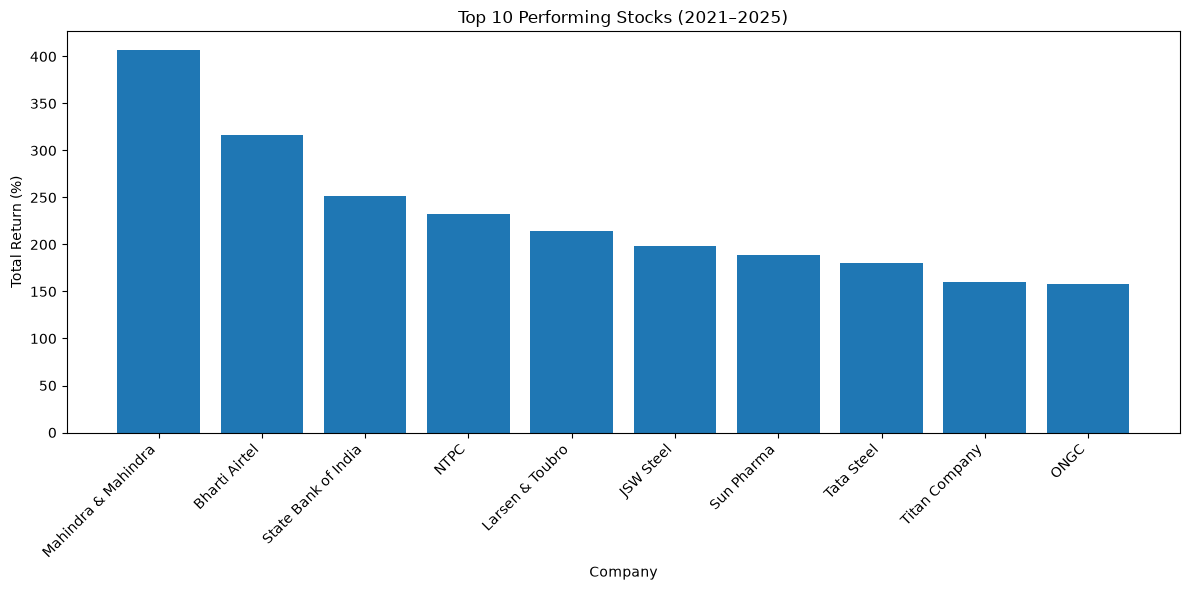

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    top_10_stocks["Company"],
    top_10_stocks["Total_Return_%"]
)

plt.title("Top 10 Performing Stocks (2021–2025)")
plt.xlabel("Company")
plt.ylabel("Total Return (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [19]:
# =========================================
# RISK & VOLATILITY ANALYSIS
# =========================================

# Calculate annualized volatility
# using daily returns

volatility_analysis = (
    df.groupby(["Ticker", "Company", "Sector"])
      .agg(
          Average_Daily_Return=("Daily_Return", "mean"),
          Daily_Volatility=("Daily_Return", "std"),
          Average_Volume=("Volume", "mean")
      )
      .reset_index()
)

# Annualized volatility
# Approximately 252 trading days per year

volatility_analysis["Annualized_Volatility_%"] = (
    volatility_analysis["Daily_Volatility"] * np.sqrt(252)
)

# Round values
volatility_analysis[
    [
        "Average_Daily_Return",
        "Daily_Volatility",
        "Annualized_Volatility_%"
    ]
] = volatility_analysis[
    [
        "Average_Daily_Return",
        "Daily_Volatility",
        "Annualized_Volatility_%"
    ]
].round(4)

# Sort from highest to lowest volatility

volatility_analysis = volatility_analysis.sort_values(
    "Annualized_Volatility_%",
    ascending=False
)

volatility_analysis

,Ticker,Company,Sector,Average_Daily_Return,Daily_Volatility,Average_Volume,Annualized_Volatility_%
21,TATASTEEL.NS,Tata Steel,Metals,0.1052,2.0845,6.860879e+07,33.0900
17,ONGC.NS,ONGC,Oil & Gas,0.0972,2.0183,1.786905e+07,32.0397
10,JSWSTEEL.NS,JSW Steel,Metals,0.1063,1.8751,3.864707e+06,29.7662
13,M&M.NS,Mahindra & Mahindra,Automobile,0.1474,1.7936,3.261248e+06,28.4725
19,SBIN.NS,State Bank of India,Banking,0.1156,1.6574,1.897707e+07,26.3102
16,NTPC.NS,NTPC,Power,0.1108,1.6364,1.524976e+07,25.9767
24,WIPRO.NS,Wipro,IT,0.0380,1.6333,1.457534e+07,25.9272
1,AXISBANK.NS,Axis Bank,Banking,0.0701,1.5844,9.873129e+06,25.1518
23,TITAN.NS,Titan Company,Consumer,0.0889,1.5244,1.229909e+06,24.1985
4,HCLTECH.NS,HCL Technologies,IT,0.0549,1.5229,3.476788e+06,24.1757


In [20]:
most_volatile = volatility_analysis.head(10)

most_volatile[
    [
        "Company",
        "Sector",
        "Annualized_Volatility_%"
    ]
]

,Company,Sector,Annualized_Volatility_%
21,Tata Steel,Metals,33.0900
17,ONGC,Oil & Gas,32.0397
10,JSW Steel,Metals,29.7662
13,Mahindra & Mahindra,Automobile,28.4725
19,State Bank of India,Banking,26.3102
16,NTPC,Power,25.9767
24,Wipro,IT,25.9272
1,Axis Bank,Banking,25.1518
23,Titan Company,Consumer,24.1985
4,HCL Technologies,IT,24.1757


In [21]:
least_volatile = volatility_analysis.tail(10)

least_volatile[
    [
        "Company",
        "Sector",
        "Annualized_Volatility_%"
    ]
]

,Company,Sector,Annualized_Volatility_%
18,Reliance Industries,Energy,22.7315
2,Bharti Airtel,Telecom,22.7011
7,ICICI Bank,Banking,22.0774
5,HDFC Bank,Banking,21.2796
20,Sun Pharma,Pharmaceuticals,20.9319
22,TCS,IT,20.7875
9,ITC,FMCG,20.2851
6,Hindustan Unilever,FMCG,20.1482
15,Nestlé India,FMCG,18.6594
25,NIFTY 50,Market Index,13.9877


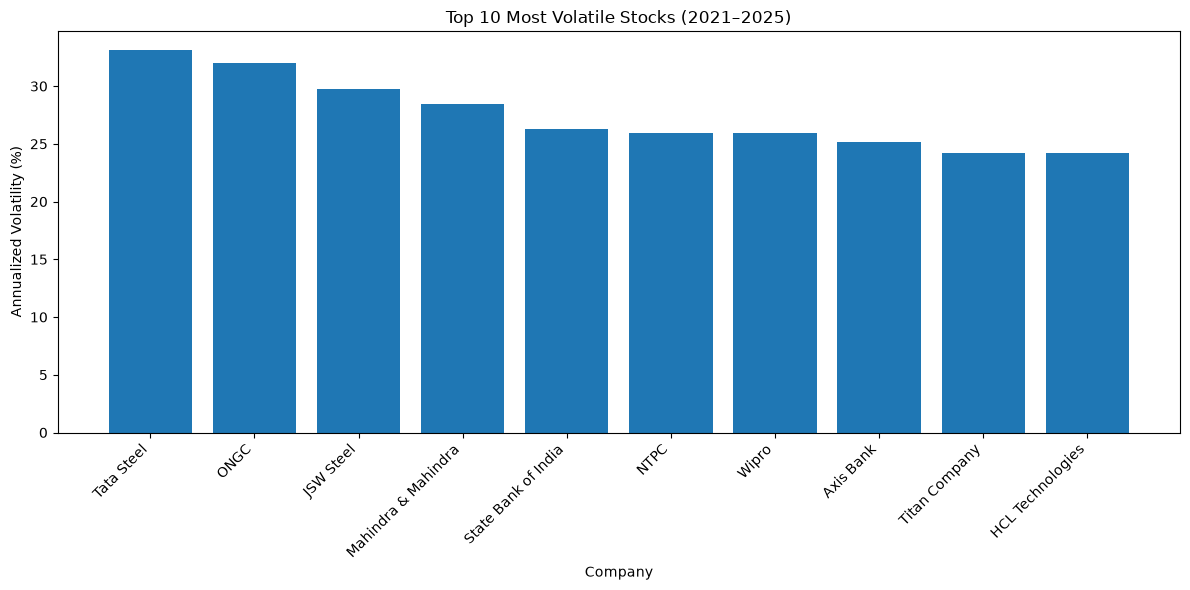

In [22]:
plt.figure(figsize=(12, 6))

plt.bar(
    most_volatile["Company"],
    most_volatile["Annualized_Volatility_%"]
)

plt.title("Top 10 Most Volatile Stocks (2021–2025)")
plt.xlabel("Company")
plt.ylabel("Annualized Volatility (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [23]:
# Combine return and volatility

risk_return = pd.merge(
    stock_performance[
        [
            "Ticker",
            "Company",
            "Sector",
            "Total_Return_%"
        ]
    ],
    volatility_analysis[
        [
            "Ticker",
            "Annualized_Volatility_%"
        ]
    ],
    on="Ticker",
    how="inner"
)

risk_return

,Ticker,Company,Sector,Total_Return_%,Annualized_Volatility_%
0,M&M.NS,Mahindra & Mahindra,Automobile,406.409994,28.4725
1,BHARTIARTL.NS,Bharti Airtel,Telecom,316.409348,22.7011
2,SBIN.NS,State Bank of India,Banking,251.539012,26.3102
3,NTPC.NS,NTPC,Power,232.710752,25.9767
4,LT.NS,Larsen & Toubro,Infrastructure,214.841943,24.0707
5,JSWSTEEL.NS,JSW Steel,Metals,198.896587,29.7662
6,SUNPHARMA.NS,Sun Pharma,Pharmaceuticals,188.419287,20.9319
7,TATASTEEL.NS,Tata Steel,Metals,180.018660,33.0900
8,TITAN.NS,Titan Company,Consumer,159.944822,24.1985
9,ONGC.NS,ONGC,Oil & Gas,157.918455,32.0397


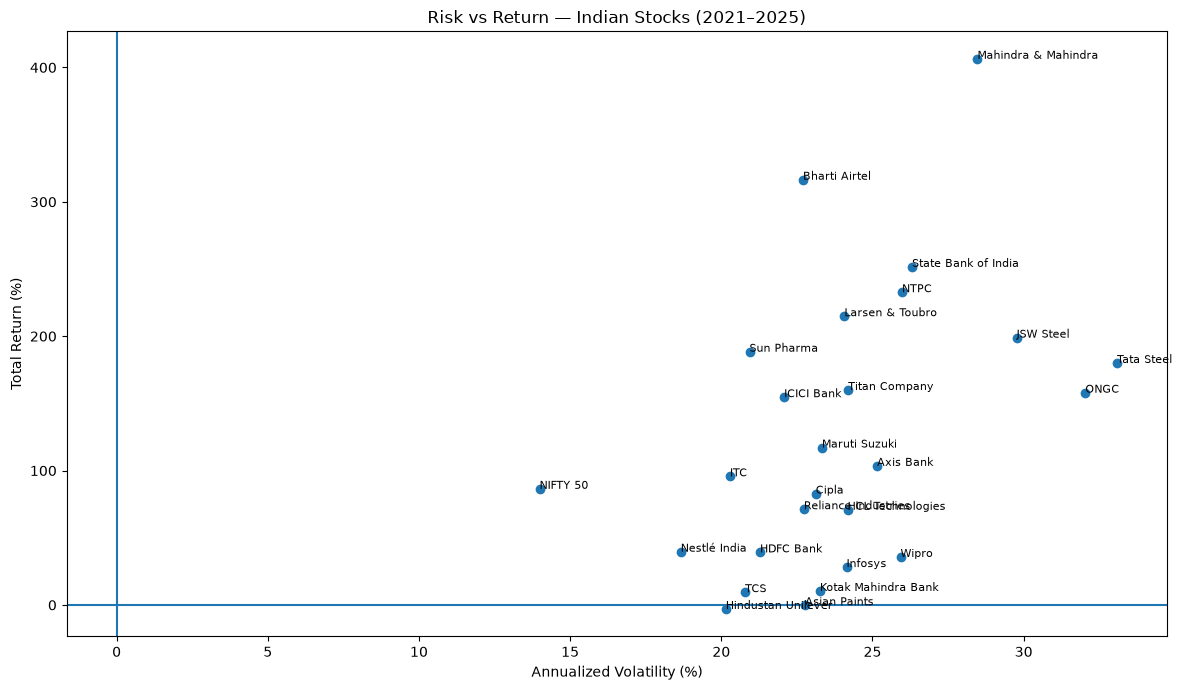

In [24]:
plt.figure(figsize=(12, 7))

plt.scatter(
    risk_return["Annualized_Volatility_%"],
    risk_return["Total_Return_%"]
)

for _, row in risk_return.iterrows():

    plt.annotate(
        row["Company"],
        (
            row["Annualized_Volatility_%"],
            row["Total_Return_%"]
        ),
        fontsize=8
    )

plt.title("Risk vs Return — Indian Stocks (2021–2025)")
plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Total Return (%)")

plt.axhline(0)
plt.axvline(0)

plt.tight_layout()
plt.show()

In [25]:
# =========================================
# SECTOR PERFORMANCE ANALYSIS
# =========================================

sector_performance = (
    risk_return
    .groupby("Sector")
    .agg(
        Average_Return=("Total_Return_%", "mean"),
        Average_Volatility=("Annualized_Volatility_%", "mean"),
        Number_of_Stocks=("Ticker", "count")
    )
    .reset_index()
)

sector_performance = sector_performance.sort_values(
    "Average_Return",
    ascending=False
)

sector_performance[
    [
        "Average_Return",
        "Average_Volatility"
    ]
] = sector_performance[
    [
        "Average_Return",
        "Average_Volatility"
    ]
].round(2)

sector_performance

,Sector,Average_Return,Average_Volatility,Number_of_Stocks
12,Telecom,316.41,22.70,1
0,Automobile,261.75,25.90,2
11,Power,232.71,25.98,1
6,Infrastructure,214.84,24.07,1
8,Metals,189.46,31.43,2
9,Oil & Gas,157.92,32.04,1
10,Pharmaceuticals,135.63,22.03,2
1,Banking,111.82,23.62,5
7,Market Index,86.39,13.99,1
2,Consumer,79.86,23.49,2


In [26]:
best_sectors = sector_performance.head(5)

best_sectors

,Sector,Average_Return,Average_Volatility,Number_of_Stocks
12,Telecom,316.41,22.70,1
0,Automobile,261.75,25.90,2
11,Power,232.71,25.98,1
6,Infrastructure,214.84,24.07,1
8,Metals,189.46,31.43,2


In [27]:
most_volatile_sectors = (
    sector_performance
    .sort_values(
        "Average_Volatility",
        ascending=False
    )
    .head(5)
)

most_volatile_sectors

,Sector,Average_Return,Average_Volatility,Number_of_Stocks
9,Oil & Gas,157.92,32.04,1
8,Metals,189.46,31.43,2
11,Power,232.71,25.98,1
0,Automobile,261.75,25.90,2
6,Infrastructure,214.84,24.07,1


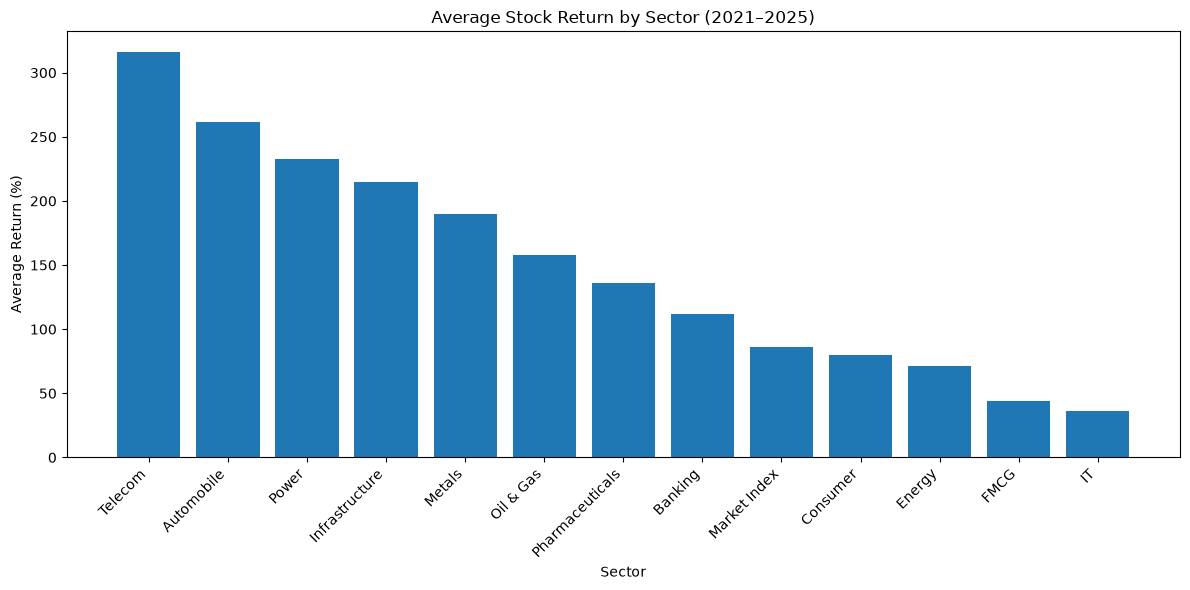

In [28]:
plt.figure(figsize=(12, 6))

plt.bar(
    sector_performance["Sector"],
    sector_performance["Average_Return"]
)

plt.title("Average Stock Return by Sector (2021–2025)")
plt.xlabel("Sector")
plt.ylabel("Average Return (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

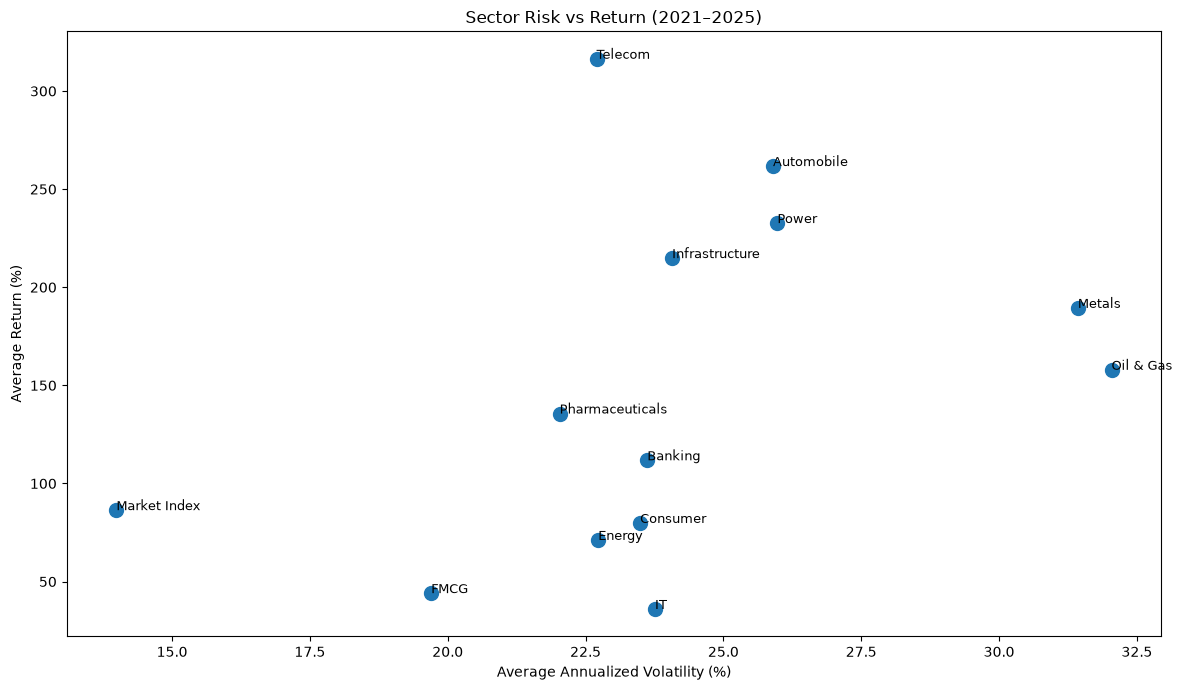

In [29]:
plt.figure(figsize=(12, 7))

plt.scatter(
    sector_performance["Average_Volatility"],
    sector_performance["Average_Return"],
    s=100
)

for _, row in sector_performance.iterrows():

    plt.annotate(
        row["Sector"],
        (
            row["Average_Volatility"],
            row["Average_Return"]
        ),
        fontsize=9
    )

plt.title("Sector Risk vs Return (2021–2025)")
plt.xlabel("Average Annualized Volatility (%)")
plt.ylabel("Average Return (%)")

plt.tight_layout()
plt.show()

In [30]:
# =========================================
# NIFTY 50 BENCHMARK ANALYSIS
# =========================================

# Get NIFTY 50 performance

nifty = df[df["Ticker"] == "^NSEI"].copy()

nifty_start = nifty["Close"].iloc[0]
nifty_end = nifty["Close"].iloc[-1]

nifty_return = (
    (nifty_end - nifty_start) /
    nifty_start
) * 100

print("NIFTY 50 Starting Price:", round(nifty_start, 2))
print("NIFTY 50 Ending Price:", round(nifty_end, 2))
print("NIFTY 50 Total Return:", round(nifty_return, 2), "%")

NIFTY 50 Starting Price: 14018.5
NIFTY 50 Ending Price: 26129.6
NIFTY 50 Total Return: 86.39 %


In [31]:
# Calculate stock performance relative to NIFTY 50

benchmark_comparison = stock_performance.copy()

benchmark_comparison["NIFTY_50_Return_%"] = nifty_return

benchmark_comparison["Excess_Return_%"] = (
    benchmark_comparison["Total_Return_%"] -
    benchmark_comparison["NIFTY_50_Return_%"]
)

benchmark_comparison = benchmark_comparison.sort_values(
    "Excess_Return_%",
    ascending=False
)

benchmark_comparison[
    [
        "Company",
        "Sector",
        "Total_Return_%",
        "NIFTY_50_Return_%",
        "Excess_Return_%"
    ]
]

,Company,Sector,Total_Return_%,NIFTY_50_Return_%,Excess_Return_%
13,Mahindra & Mahindra,Automobile,406.409994,86.393691,320.016303
2,Bharti Airtel,Telecom,316.409348,86.393691,230.015656
19,State Bank of India,Banking,251.539012,86.393691,165.145321
16,NTPC,Power,232.710752,86.393691,146.317061
12,Larsen & Toubro,Infrastructure,214.841943,86.393691,128.448252
10,JSW Steel,Metals,198.896587,86.393691,112.502896
20,Sun Pharma,Pharmaceuticals,188.419287,86.393691,102.025596
21,Tata Steel,Metals,180.018660,86.393691,93.624968
23,Titan Company,Consumer,159.944822,86.393691,73.551131
17,ONGC,Oil & Gas,157.918455,86.393691,71.524764


In [32]:
top_outperformers = benchmark_comparison.head(10)

top_outperformers[
    [
        "Company",
        "Sector",
        "Total_Return_%",
        "NIFTY_50_Return_%",
        "Excess_Return_%"
    ]
]

,Company,Sector,Total_Return_%,NIFTY_50_Return_%,Excess_Return_%
13,Mahindra & Mahindra,Automobile,406.409994,86.393691,320.016303
2,Bharti Airtel,Telecom,316.409348,86.393691,230.015656
19,State Bank of India,Banking,251.539012,86.393691,165.145321
16,NTPC,Power,232.710752,86.393691,146.317061
12,Larsen & Toubro,Infrastructure,214.841943,86.393691,128.448252
10,JSW Steel,Metals,198.896587,86.393691,112.502896
20,Sun Pharma,Pharmaceuticals,188.419287,86.393691,102.025596
21,Tata Steel,Metals,180.018660,86.393691,93.624968
23,Titan Company,Consumer,159.944822,86.393691,73.551131
17,ONGC,Oil & Gas,157.918455,86.393691,71.524764


In [33]:
top_underperformers = benchmark_comparison.tail(10)

top_underperformers[
    [
        "Company",
        "Sector",
        "Total_Return_%",
        "NIFTY_50_Return_%",
        "Excess_Return_%"
    ]
]

,Company,Sector,Total_Return_%,NIFTY_50_Return_%,Excess_Return_%
18,Reliance Industries,Energy,71.210960,86.393691,-15.182731
4,HCL Technologies,IT,70.783798,86.393691,-15.609893
15,Nestlé India,FMCG,39.615299,86.393691,-46.778392
5,HDFC Bank,Banking,39.110908,86.393691,-47.282783
24,Wipro,IT,35.676372,86.393691,-50.717319
8,Infosys,IT,28.160578,86.393691,-58.233114
11,Kotak Mahindra Bank,Banking,10.383391,86.393691,-76.010301
22,TCS,IT,9.492017,86.393691,-76.901674
0,Asian Paints,Consumer,-0.217975,86.393691,-86.611666
6,Hindustan Unilever,FMCG,-3.000988,86.393691,-89.394680


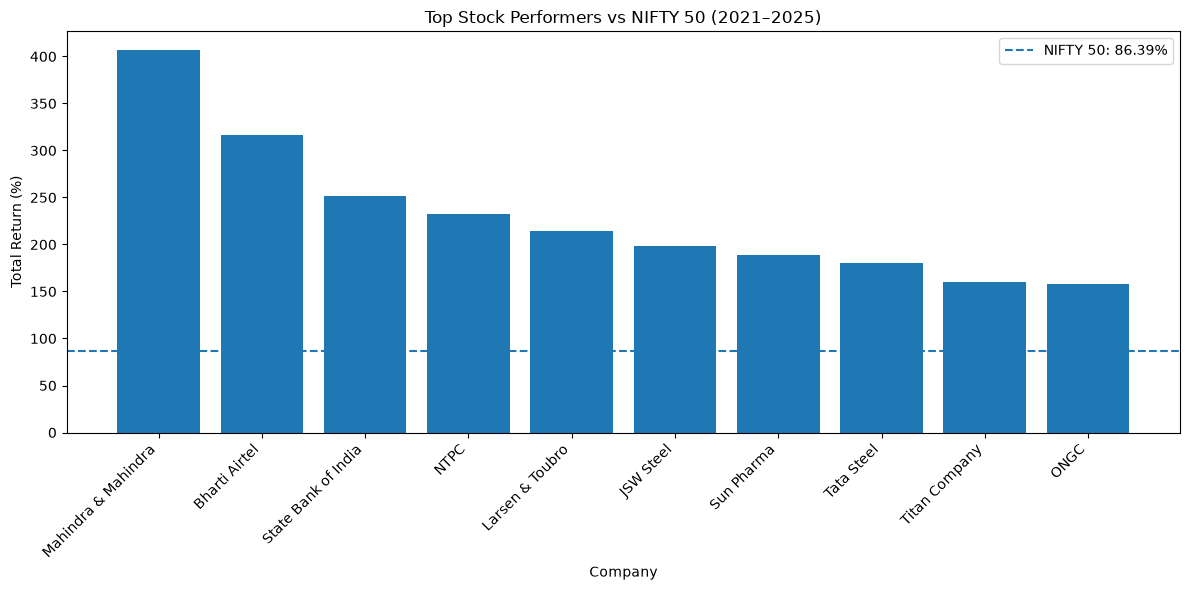

In [34]:
# Top outperformers vs NIFTY 50

comparison_chart = top_outperformers.copy()

plt.figure(figsize=(12, 6))

plt.bar(
    comparison_chart["Company"],
    comparison_chart["Total_Return_%"]
)

plt.axhline(
    nifty_return,
    linestyle="--",
    label=f"NIFTY 50: {nifty_return:.2f}%"
)

plt.title("Top Stock Performers vs NIFTY 50 (2021–2025)")
plt.xlabel("Company")
plt.ylabel("Total Return (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend()

plt.tight_layout()
plt.show()

In [35]:
# Count stocks that outperformed and underperformed NIFTY 50

outperformed = (
    benchmark_comparison["Excess_Return_%"] > 0
).sum()

underperformed = (
    benchmark_comparison["Excess_Return_%"] < 0
).sum()

equal_to_market = (
    benchmark_comparison["Excess_Return_%"] == 0
).sum()

print("Stocks that outperformed NIFTY 50:", outperformed)
print("Stocks that underperformed NIFTY 50:", underperformed)
print("Stocks with equal performance:", equal_to_market)

Stocks that outperformed NIFTY 50: 14
Stocks that underperformed NIFTY 50: 11
Stocks with equal performance: 1


In [36]:
# =========================================
# TIME-BASED ANALYSIS
# =========================================

# Make sure Date is in datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Create time dimensions
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")
df["Year_Month"] = df["Date"].dt.to_period("M").astype(str)

print(df[["Date", "Year", "Month", "Month_Name", "Year_Month"]].head())

        Date  Year  Month Month_Name Year_Month
0 2021-01-01  2021      1        Jan    2021-01
1 2021-01-04  2021      1        Jan    2021-01
2 2021-01-05  2021      1        Jan    2021-01
3 2021-01-06  2021      1        Jan    2021-01
4 2021-01-07  2021      1        Jan    2021-01


In [37]:
# Monthly closing price for each stock
monthly_prices = (
    df.sort_values("Date")
      .groupby(["Ticker", "Company", "Sector", "Year_Month"])
      .agg(
          Month_End_Price=("Close", "last")
      )
      .reset_index()
)

# Calculate monthly return
monthly_prices["Monthly_Return_%"] = (
    monthly_prices
    .groupby("Ticker")["Month_End_Price"]
    .pct_change() * 100
)

monthly_prices["Monthly_Return_%"] = (
    monthly_prices["Monthly_Return_%"].round(2)
)

monthly_prices.head(20)

,Ticker,Company,Sector,Year_Month,Month_End_Price,Monthly_Return_%
0,ASIANPAINT.NS,Asian Paints,Consumer,2021-01,2407.3501,NaN
1,ASIANPAINT.NS,Asian Paints,Consumer,2021-02,2277.2000,-5.41
2,ASIANPAINT.NS,Asian Paints,Consumer,2021-03,2537.3999,11.43
3,ASIANPAINT.NS,Asian Paints,Consumer,2021-04,2536.3999,-0.04
4,ASIANPAINT.NS,Asian Paints,Consumer,2021-05,2977.5000,17.39
5,ASIANPAINT.NS,Asian Paints,Consumer,2021-06,2992.7000,0.51
6,ASIANPAINT.NS,Asian Paints,Consumer,2021-07,2958.4500,-1.14
7,ASIANPAINT.NS,Asian Paints,Consumer,2021-08,3201.3501,8.21
8,ASIANPAINT.NS,Asian Paints,Consumer,2021-09,3244.6499,1.35
9,ASIANPAINT.NS,Asian Paints,Consumer,2021-10,3100.1001,-4.46


In [38]:
best_months = (
    monthly_prices
    .dropna(subset=["Monthly_Return_%"])
    .sort_values("Monthly_Return_%", ascending=False)
    .head(10)
)

print("Top 10 stock-month performances:")

best_months[
    [
        "Company",
        "Sector",
        "Year_Month",
        "Monthly_Return_%"
    ]
]

Top 10 stock-month performances:


,Company,Sector,Year_Month,Monthly_Return_%
603,JSW Steel,Metals,2021-04,53.24
1141,State Bank of India,Banking,2021-02,38.30
1263,Tata Steel,Metals,2021-04,27.36
1021,ONGC,Oil & Gas,2021-02,25.71
1278,Tata Steel,Metals,2022-07,24.10
18,Asian Paints,Consumer,2022-07,23.69
81,Axis Bank,Banking,2022-10,23.57
1056,ONGC,Oil & Gas,2024-01,23.02
1266,Tata Steel,Metals,2021-07,22.95
968,NTPC,Power,2021-09,22.34


In [39]:
worst_months = (
    monthly_prices
    .dropna(subset=["Monthly_Return_%"])
    .sort_values("Monthly_Return_%")
    .head(10)
)

print("Worst 10 stock-month performances:")

worst_months[
    [
        "Company",
        "Sector",
        "Year_Month",
        "Monthly_Return_%"
    ]
]

Worst 10 stock-month performances:


,Company,Sector,Year_Month,Monthly_Return_%
616,JSW Steel,Metals,2022-05,-24.19
1452,Wipro,IT,2022-01,-19.96
1270,Tata Steel,Metals,2021-11,-18.60
1277,Tata Steel,Metals,2022-06,-17.87
495,Infosys,IT,2022-04,-17.79
1276,Tata Steel,Metals,2022-05,-16.95
252,HCL Technologies,IT,2022-01,-16.66
885,Maruti Suzuki,Automobile,2024-10,-16.33
945,Nestlé India,FMCG,2024-10,-15.87
46,Asian Paints,Consumer,2024-11,-15.53


In [40]:
# =========================================
# YEARLY PERFORMANCE
# =========================================

yearly_prices = (
    df.sort_values("Date")
      .groupby(["Ticker", "Company", "Sector", "Year"])
      .agg(
          Year_Start_Price=("Close", "first"),
          Year_End_Price=("Close", "last")
      )
      .reset_index()
)

yearly_prices["Yearly_Return_%"] = (
    (
        yearly_prices["Year_End_Price"] -
        yearly_prices["Year_Start_Price"]
    )
    / yearly_prices["Year_Start_Price"]
) * 100

yearly_prices["Yearly_Return_%"] = (
    yearly_prices["Yearly_Return_%"].round(2)
)

yearly_prices

,Ticker,Company,Sector,Year,Year_Start_Price,Year_End_Price,Yearly_Return_%
0,ASIANPAINT.NS,Asian Paints,Consumer,2021,2775.5500,3382.9500,21.88
1,ASIANPAINT.NS,Asian Paints,Consumer,2022,3422.3999,3087.8999,-9.77
2,ASIANPAINT.NS,Asian Paints,Consumer,2023,3047.2500,3402.3999,11.65
3,ASIANPAINT.NS,Asian Paints,Consumer,2024,3396.1001,2281.3501,-32.82
4,ASIANPAINT.NS,Asian Paints,Consumer,2025,2304.6499,2769.5000,20.17
...,...,...,...,...,...,...,...
125,^NSEI,NIFTY 50,Market Index,2021,14018.5000,17354.0508,23.79
126,^NSEI,NIFTY 50,Market Index,2022,17625.6992,18105.3008,2.72
127,^NSEI,NIFTY 50,Market Index,2023,18197.4492,21731.4004,19.42
128,^NSEI,NIFTY 50,Market Index,2024,21741.9004,23644.8008,8.75


In [41]:
best_stock_each_year = (
    yearly_prices
    .sort_values(
        ["Year", "Yearly_Return_%"],
        ascending=[True, False]
    )
    .groupby("Year")
    .head(1)
)

best_stock_each_year[
    [
        "Year",
        "Company",
        "Sector",
        "Yearly_Return_%"
    ]
]

,Year,Company,Sector,Yearly_Return_%
120,2021,Wipro,IT,84.32
46,2022,ITC,FMCG,51.32
82,2023,NTPC,Power,85.21
68,2024,Mahindra & Mahindra,Automobile,76.55
74,2025,Maruti Suzuki,Automobile,48.97


In [42]:
worst_stock_each_year = (
    yearly_prices
    .sort_values(
        ["Year", "Yearly_Return_%"],
        ascending=[True, True]
    )
    .groupby("Year")
    .head(1)
)

worst_stock_each_year[
    [
        "Year",
        "Company",
        "Sector",
        "Yearly_Return_%"
    ]
]

,Year,Company,Sector,Yearly_Return_%
55,2021,Kotak Mahindra Bank,Banking,-9.93
121,2022,Wipro,IT,-45.35
42,2023,Infosys,IT,1.24
3,2024,Asian Paints,Consumer,-32.82
114,2025,TCS,IT,-22.04


In [43]:
nifty_yearly = yearly_prices[
    yearly_prices["Ticker"] == "^NSEI"
].copy()

nifty_yearly[
    [
        "Year",
        "Yearly_Return_%"
    ]
]

,Year,Yearly_Return_%
125,2021,23.79
126,2022,2.72
127,2023,19.42
128,2024,8.75
129,2025,10.05


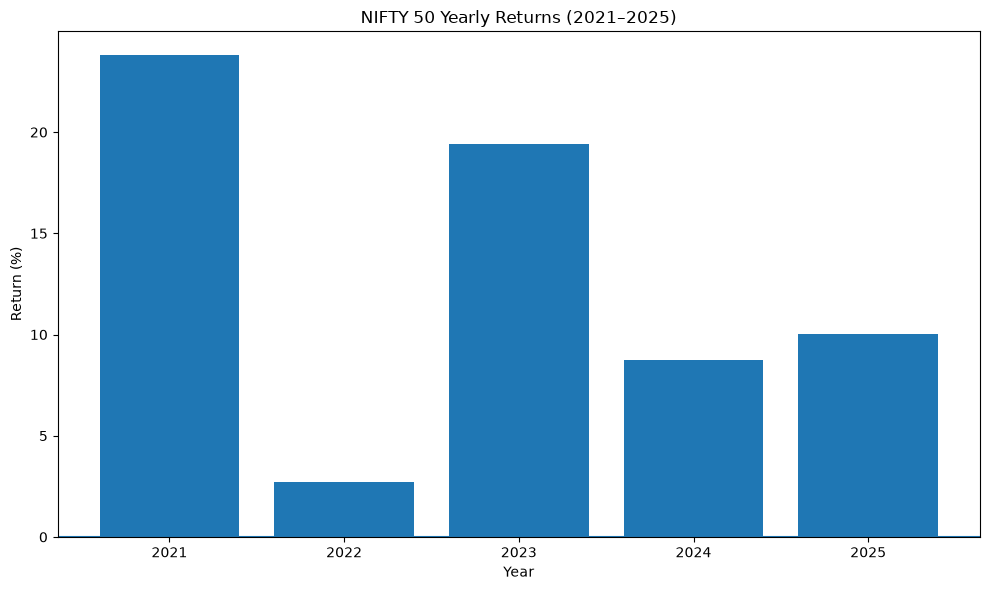

In [44]:
plt.figure(figsize=(10, 6))

plt.bar(
    nifty_yearly["Year"].astype(str),
    nifty_yearly["Yearly_Return_%"]
)

plt.axhline(0)

plt.title("NIFTY 50 Yearly Returns (2021–2025)")
plt.xlabel("Year")
plt.ylabel("Return (%)")

plt.tight_layout()
plt.show()

In [45]:
# =========================================
# MAXIMUM DRAWDOWN ANALYSIS
# =========================================

drawdown_data = df.sort_values(
    ["Ticker", "Date"]
).copy()

# Calculate running highest closing price
drawdown_data["Running_Peak"] = (
    drawdown_data
    .groupby("Ticker")["Close"]
    .cummax()
)

# Calculate drawdown percentage
drawdown_data["Drawdown_%"] = (
    (
        drawdown_data["Close"] -
        drawdown_data["Running_Peak"]
    )
    / drawdown_data["Running_Peak"]
) * 100

# Calculate maximum drawdown for each stock
max_drawdown = (
    drawdown_data
    .groupby(["Ticker", "Company", "Sector"])
    .agg(
        Maximum_Drawdown=("Drawdown_%", "min")
    )
    .reset_index()
)

max_drawdown["Maximum_Drawdown_%"] = (
    max_drawdown["Maximum_Drawdown"].round(2)
)

max_drawdown = max_drawdown.sort_values(
    "Maximum_Drawdown_%"
)

max_drawdown[
    [
        "Company",
        "Sector",
        "Maximum_Drawdown_%"
    ]
]

,Company,Sector,Maximum_Drawdown_%
24,Wipro,IT,-50.63
21,Tata Steel,Metals,-44.84
0,Asian Paints,Consumer,-40.38
8,Infosys,IT,-36.92
22,TCS,IT,-36.57
17,ONGC,Oil & Gas,-35.67
4,HCL Technologies,IT,-34.98
16,NTPC,Power,-32.72
10,JSW Steel,Metals,-31.18
6,Hindustan Unilever,FMCG,-30.88


In [46]:
largest_drawdowns = max_drawdown.head(10)

largest_drawdowns[
    [
        "Company",
        "Sector",
        "Maximum_Drawdown_%"
    ]
]

,Company,Sector,Maximum_Drawdown_%
24,Wipro,IT,-50.63
21,Tata Steel,Metals,-44.84
0,Asian Paints,Consumer,-40.38
8,Infosys,IT,-36.92
22,TCS,IT,-36.57
17,ONGC,Oil & Gas,-35.67
4,HCL Technologies,IT,-34.98
16,NTPC,Power,-32.72
10,JSW Steel,Metals,-31.18
6,Hindustan Unilever,FMCG,-30.88


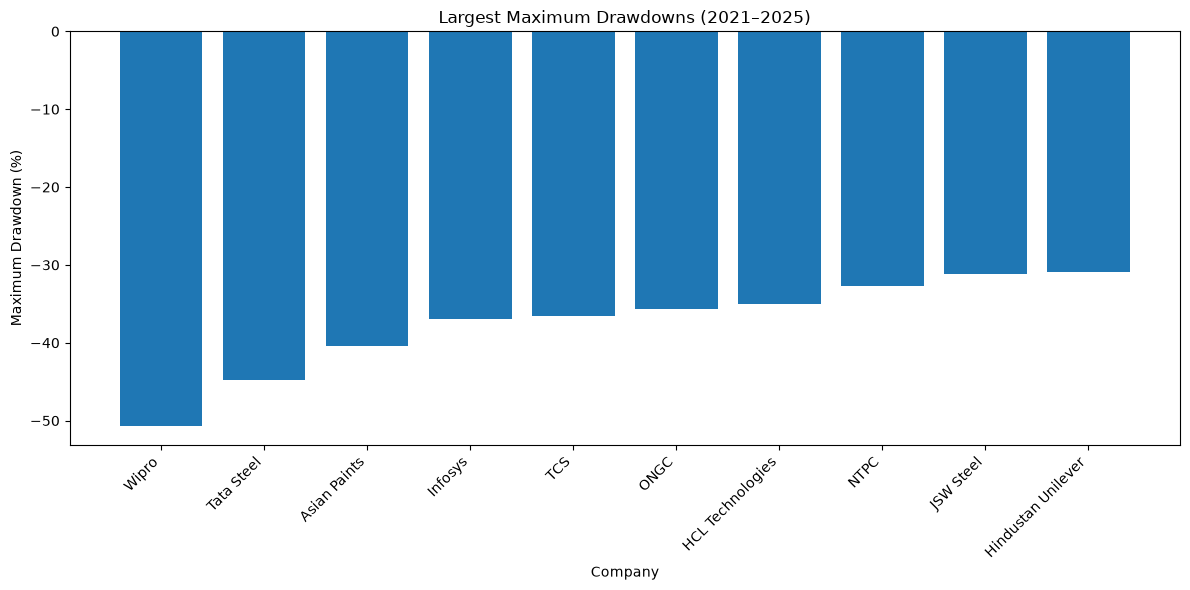

In [47]:
plt.figure(figsize=(12, 6))

plt.bar(
    largest_drawdowns["Company"],
    largest_drawdowns["Maximum_Drawdown_%"]
)

plt.title("Largest Maximum Drawdowns (2021–2025)")
plt.xlabel("Company")
plt.ylabel("Maximum Drawdown (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [48]:
# =========================================
# MASTER STOCK PERFORMANCE TABLE
# =========================================

master_stock_analysis = pd.merge(
    stock_performance,
    volatility_analysis[
        [
            "Ticker",
            "Annualized_Volatility_%"
        ]
    ],
    on="Ticker",
    how="left"
)

master_stock_analysis = pd.merge(
    master_stock_analysis,
    max_drawdown[
        [
            "Ticker",
            "Maximum_Drawdown_%"
        ]
    ],
    on="Ticker",
    how="left"
)

master_stock_analysis = master_stock_analysis[
    [
        "Ticker",
        "Company",
        "Sector",
        "Start_Price",
        "End_Price",
        "Average_Price",
        "Highest_Price",
        "Lowest_Price",
        "Total_Volume",
        "Total_Return_%",
        "Annualized_Volatility_%",
        "Maximum_Drawdown_%"
    ]
]

master_stock_analysis = (
    master_stock_analysis
    .sort_values(
        "Total_Return_%",
        ascending=False
    )
    .reset_index(drop=True)
)

master_stock_analysis

,Ticker,Company,Sector,Start_Price,End_Price,Average_Price,Highest_Price,Lowest_Price,Total_Volume,Total_Return_%,Annualized_Volatility_%,Maximum_Drawdown_%
0,M&M.NS,Mahindra & Mahindra,Automobile,732.4500,3709.2000,1803.384589,3757.3000,690.5500,4030902911,406.409994,28.4725,-28.09
1,BHARTIARTL.NS,Bharti Airtel,Telecom,505.6563,2105.6001,1094.921309,2162.7000,498.3927,10294293768,316.409348,22.7011,-17.37
2,SBIN.NS,State Bank of India,Banking,279.4000,982.2000,625.523341,983.9000,275.6500,23455657931,251.539012,26.3102,-23.94
3,NTPC.NS,NTPC,Power,99.0500,329.5500,235.545550,443.2000,88.9500,18848706518,232.710752,25.9767,-32.72
4,LT.NS,Larsen & Toubro,Infrastructure,1297.0000,4083.5000,2637.071278,4092.3000,1297.0000,2805704987,214.841943,24.0707,-28.88
5,JSWSTEEL.NS,JSW Steel,Metals,389.7000,1164.8000,796.267961,1210.0000,366.8500,4776777880,198.896587,29.7662,-31.18
6,SUNPHARMA.NS,Sun Pharma,Pharmaceuticals,596.2500,1719.7000,1205.998786,1948.7000,564.3500,3871508228,188.419287,20.9319,-19.78
7,TATASTEEL.NS,Tata Steel,Metals,64.3100,180.0800,129.469502,185.1900,60.1000,84800462185,180.018660,33.0900,-44.84
8,TITAN.NS,Titan Company,Consumer,1558.6000,4051.5000,2841.518204,4051.5000,1402.9000,1520167446,159.944822,24.1985,-28.63
9,ONGC.NS,ONGC,Oil & Gas,93.2000,240.3800,191.796351,341.7500,88.3000,22086145112,157.918455,32.0397,-35.67


In [49]:
# Remove NIFTY 50 from individual-stock analysis

company_analysis = master_stock_analysis[
    master_stock_analysis["Ticker"] != "^NSEI"
].copy()

print("Companies analyzed:", len(company_analysis))

company_analysis

Companies analyzed: 25


,Ticker,Company,Sector,Start_Price,End_Price,Average_Price,Highest_Price,Lowest_Price,Total_Volume,Total_Return_%,Annualized_Volatility_%,Maximum_Drawdown_%
0,M&M.NS,Mahindra & Mahindra,Automobile,732.4500,3709.2000,1803.384589,3757.300,690.5500,4030902911,406.409994,28.4725,-28.09
1,BHARTIARTL.NS,Bharti Airtel,Telecom,505.6563,2105.6001,1094.921309,2162.700,498.3927,10294293768,316.409348,22.7011,-17.37
2,SBIN.NS,State Bank of India,Banking,279.4000,982.2000,625.523341,983.900,275.6500,23455657931,251.539012,26.3102,-23.94
3,NTPC.NS,NTPC,Power,99.0500,329.5500,235.545550,443.200,88.9500,18848706518,232.710752,25.9767,-32.72
4,LT.NS,Larsen & Toubro,Infrastructure,1297.0000,4083.5000,2637.071278,4092.300,1297.0000,2805704987,214.841943,24.0707,-28.88
5,JSWSTEEL.NS,JSW Steel,Metals,389.7000,1164.8000,796.267961,1210.000,366.8500,4776777880,198.896587,29.7662,-31.18
6,SUNPHARMA.NS,Sun Pharma,Pharmaceuticals,596.2500,1719.7000,1205.998786,1948.700,564.3500,3871508228,188.419287,20.9319,-19.78
7,TATASTEEL.NS,Tata Steel,Metals,64.3100,180.0800,129.469502,185.190,60.1000,84800462185,180.018660,33.0900,-44.84
8,TITAN.NS,Titan Company,Consumer,1558.6000,4051.5000,2841.518204,4051.500,1402.9000,1520167446,159.944822,24.1985,-28.63
9,ONGC.NS,ONGC,Oil & Gas,93.2000,240.3800,191.796351,341.750,88.3000,22086145112,157.918455,32.0397,-35.67


In [50]:
# =========================================
# EXPORT ANALYSIS TO EXCEL
# =========================================

excel_file = "../excel/india_stock_market_analysis.xlsx"

# Make sure the Excel folder exists
os.makedirs("../excel", exist_ok=True)

# Create Excel workbook
with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:

    # 1. Cleaned daily data
    df.to_excel(
        writer,
        sheet_name="Daily_Data",
        index=False
    )

    # 2. Company analysis
    company_analysis.to_excel(
        writer,
        sheet_name="Company_Analysis",
        index=False
    )

    # 3. Sector analysis
    sector_performance.to_excel(
        writer,
        sheet_name="Sector_Analysis",
        index=False
    )

    # 4. Yearly performance
    yearly_prices.to_excel(
        writer,
        sheet_name="Yearly_Performance",
        index=False
    )

    # 5. Monthly performance
    monthly_prices.to_excel(
        writer,
        sheet_name="Monthly_Performance",
        index=False
    )

    # 6. NIFTY benchmark comparison
    benchmark_comparison.to_excel(
        writer,
        sheet_name="Benchmark_Comparison",
        index=False
    )

    # 7. Risk vs Return
    risk_return.to_excel(
        writer,
        sheet_name="Risk_Return",
        index=False
    )

print("Excel workbook created successfully!")
print("Saved to:", excel_file)

Excel workbook created successfully!
Saved to: ../excel/india_stock_market_analysis.xlsx


In [51]:
# =========================================
# DOWNLOAD ADJUSTED STOCK MARKET DATA
# =========================================

import pandas as pd
import yfinance as yf
import os

# -----------------------------------------
# Stock list
# -----------------------------------------

stocks = {
    "RELIANCE.NS": ("Reliance Industries", "Energy"),
    "HDFCBANK.NS": ("HDFC Bank", "Banking"),
    "ICICIBANK.NS": ("ICICI Bank", "Banking"),
    "SBIN.NS": ("State Bank of India", "Banking"),
    "AXISBANK.NS": ("Axis Bank", "Banking"),
    "KOTAKBANK.NS": ("Kotak Mahindra Bank", "Banking"),
    "TCS.NS": ("TCS", "IT"),
    "INFY.NS": ("Infosys", "IT"),
    "HCLTECH.NS": ("HCL Technologies", "IT"),
    "WIPRO.NS": ("Wipro", "IT"),
    "BHARTIARTL.NS": ("Bharti Airtel", "Telecom"),
    "LT.NS": ("Larsen & Toubro", "Infrastructure"),
    "MARUTI.NS": ("Maruti Suzuki", "Automobile"),
    "M&M.NS": ("Mahindra & Mahindra", "Automobile"),
    "SUNPHARMA.NS": ("Sun Pharma", "Pharmaceuticals"),
    "CIPLA.NS": ("Cipla", "Pharmaceuticals"),
    "ITC.NS": ("ITC", "FMCG"),
    "HINDUNILVR.NS": ("Hindustan Unilever", "FMCG"),
    "NESTLEIND.NS": ("Nestlé India", "FMCG"),
    "TITAN.NS": ("Titan Company", "Consumer"),
    "ASIANPAINT.NS": ("Asian Paints", "Consumer"),
    "TATASTEEL.NS": ("Tata Steel", "Metals"),
    "JSWSTEEL.NS": ("JSW Steel", "Metals"),
    "NTPC.NS": ("NTPC", "Power"),
    "ONGC.NS": ("ONGC", "Oil & Gas")
}

# NIFTY 50 benchmark
stocks["^NSEI"] = ("NIFTY 50", "Market Index")


# -----------------------------------------
# Download adjusted historical data
# -----------------------------------------

all_data = []

for ticker, (company, sector) in stocks.items():

    print(f"Downloading adjusted data for {company}...")

    data = yf.download(
        ticker,
        start="2021-01-01",
        end="2026-01-01",
        auto_adjust=True,
        progress=False
    )

    if data.empty:
        print(f"WARNING: No data found for {company}")
        continue

    # Handle MultiIndex columns
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data = data.reset_index()

    # Add identification columns
    data["Ticker"] = ticker
    data["Company"] = company
    data["Sector"] = sector

    all_data.append(data)


# -----------------------------------------
# Combine all data
# -----------------------------------------

adjusted_data = pd.concat(
    all_data,
    ignore_index=True
)


# -----------------------------------------
# Clean column names
# -----------------------------------------

adjusted_data.columns = [
    str(col).strip().replace(" ", "_")
    for col in adjusted_data.columns
]


# Keep the columns available from
# auto_adjust=True

adjusted_data = adjusted_data[
    [
        "Date",
        "Ticker",
        "Company",
        "Sector",
        "Open",
        "High",
        "Low",
        "Close",
        "Volume"
    ]
]


# -----------------------------------------
# Sort data
# -----------------------------------------

adjusted_data = adjusted_data.sort_values(
    ["Ticker", "Date"]
).reset_index(drop=True)


# -----------------------------------------
# Save adjusted raw data
# -----------------------------------------

os.makedirs("../data/raw", exist_ok=True)

adjusted_raw_file = (
    "../data/raw/"
    "india_stock_market_adjusted_raw.csv"
)

adjusted_data.to_csv(
    adjusted_raw_file,
    index=False
)


# -----------------------------------------
# Final report
# -----------------------------------------

print("\n=========================================")
print("ADJUSTED DATA DOWNLOAD COMPLETED")
print("=========================================")

print("Rows:", len(adjusted_data))
print("Columns:", len(adjusted_data.columns))
print(
    "Companies/Indexes:",
    adjusted_data["Company"].nunique()
)

print(
    "Date range:",
    adjusted_data["Date"].min(),
    "to",
    adjusted_data["Date"].max()
)

print("\nSaved to:")
print(adjusted_raw_file)


ADJUSTED DATA DOWNLOAD COMPLETED
Rows: 32136
Columns: 9
Companies/Indexes: 26
Date range: 2021-01-01 00:00:00 to 2025-12-31 00:00:00

Saved to:
../data/raw/india_stock_market_adjusted_raw.csv


In [52]:
# =========================================
# CREATE CLEANED ADJUSTED DATASET
# =========================================

df = adjusted_data.copy()

# Convert Date
df["Date"] = pd.to_datetime(df["Date"])


# Remove empty rows
df = df.dropna(how="all")


# Remove duplicates
df = df.drop_duplicates()


# Convert numeric columns
numeric_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )


# Remove rows with missing essential data
df = df.dropna(
    subset=[
        "Date",
        "Ticker",
        "Company",
        "Sector",
        "Open",
        "High",
        "Low",
        "Close",
        "Volume"
    ]
)


# Remove impossible values
df = df[
    (df["Open"] > 0) &
    (df["High"] > 0) &
    (df["Low"] > 0) &
    (df["Close"] > 0) &
    (df["Volume"] >= 0)
]


# Sort
df = df.sort_values(
    ["Ticker", "Date"]
).reset_index(drop=True)


# -----------------------------------------
# Daily calculations
# -----------------------------------------

df["Price_Change"] = (
    df.groupby("Ticker")["Close"]
    .diff()
)

df["Daily_Return"] = (
    df.groupby("Ticker")["Close"]
    .pct_change() * 100
)

df["Price_Range"] = (
    df["High"] - df["Low"]
)

df["Price_Range_Pct"] = (
    (df["High"] - df["Low"])
    / df["Low"] * 100
)


# Round calculations
calculated_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Price_Change",
    "Daily_Return",
    "Price_Range",
    "Price_Range_Pct"
]

df[calculated_columns] = (
    df[calculated_columns].round(4)
)


# -----------------------------------------
# Save corrected cleaned dataset
# -----------------------------------------

os.makedirs("../data/cleaned", exist_ok=True)

cleaned_file = (
    "../data/cleaned/"
    "india_stock_market_cleaned.csv"
)

df.to_csv(
    cleaned_file,
    index=False
)


# -----------------------------------------
# Quality report
# -----------------------------------------

print("\n=========================================")
print("CORRECTED CLEANED DATASET")
print("=========================================")

print("Rows:", len(df))
print("Columns:", len(df.columns))

print(
    "Companies/Indexes:",
    df["Company"].nunique()
)

print(
    "Date range:",
    df["Date"].min().date(),
    "to",
    df["Date"].max().date()
)

print(
    "Missing values:",
    df.isnull().sum().sum()
)

print(
    "Duplicate rows:",
    df.duplicated().sum()
)

print("\nSaved to:")
print(cleaned_file)


CORRECTED CLEANED DATASET
Rows: 32136
Columns: 13
Companies/Indexes: 26
Date range: 2021-01-01 to 2025-12-31
Missing values: 52
Duplicate rows: 0

Saved to:
../data/cleaned/india_stock_market_cleaned.csv


In [53]:
# =========================================
# CHECK MAXIMUM DRAWDOWN
# =========================================

drawdown_check = df.sort_values(
    ["Ticker", "Date"]
).copy()

drawdown_check["Running_Peak"] = (
    drawdown_check
    .groupby("Ticker")["Close"]
    .cummax()
)

drawdown_check["Drawdown_%"] = (
    (
        drawdown_check["Close"] -
        drawdown_check["Running_Peak"]
    )
    / drawdown_check["Running_Peak"]
) * 100

drawdown_check["Drawdown_%"] = (
    drawdown_check["Drawdown_%"].round(2)
)

max_drawdown_check = (
    drawdown_check
    .groupby(["Ticker", "Company", "Sector"])
    .agg(
        Maximum_Drawdown=(
            "Drawdown_%",
            "min"
        )
    )
    .reset_index()
)

max_drawdown_check = (
    max_drawdown_check
    .sort_values("Maximum_Drawdown")
)

max_drawdown_check

,Ticker,Company,Sector,Maximum_Drawdown
24,WIPRO.NS,Wipro,IT,-50.02
21,TATASTEEL.NS,Tata Steel,Metals,-41.86
0,ASIANPAINT.NS,Asian Paints,Consumer,-39.04
8,INFY.NS,Infosys,IT,-35.56
17,ONGC.NS,ONGC,Oil & Gas,-35.30
22,TCS.NS,TCS,IT,-34.45
4,HCLTECH.NS,HCL Technologies,IT,-33.04
16,NTPC.NS,NTPC,Power,-32.30
10,JSWSTEEL.NS,JSW Steel,Metals,-31.18
6,HINDUNILVR.NS,Hindustan Unilever,FMCG,-30.46


In [54]:
# =========================================
# RECALCULATE COMPLETE ANALYSIS
# USING ADJUSTED DATA
# =========================================

# -----------------------------------------
# 1. Stock Performance
# -----------------------------------------

stock_performance = (
    df.groupby(["Ticker", "Company", "Sector"])
      .agg(
          Start_Price=("Close", "first"),
          End_Price=("Close", "last"),
          Average_Price=("Close", "mean"),
          Highest_Price=("Close", "max"),
          Lowest_Price=("Close", "min"),
          Total_Volume=("Volume", "sum")
      )
      .reset_index()
)

stock_performance["Total_Return_%"] = (
    (
        stock_performance["End_Price"] -
        stock_performance["Start_Price"]
    )
    / stock_performance["Start_Price"]
) * 100

stock_performance["Total_Return_%"] = (
    stock_performance["Total_Return_%"].round(2)
)

stock_performance = stock_performance.sort_values(
    "Total_Return_%",
    ascending=False
).reset_index(drop=True)


# -----------------------------------------
# 2. Volatility Analysis
# -----------------------------------------

volatility_analysis = (
    df.groupby(["Ticker", "Company", "Sector"])
      .agg(
          Average_Daily_Return=("Daily_Return", "mean"),
          Daily_Volatility=("Daily_Return", "std"),
          Average_Volume=("Volume", "mean")
      )
      .reset_index()
)

volatility_analysis["Annualized_Volatility_%"] = (
    volatility_analysis["Daily_Volatility"]
    * np.sqrt(252)
)

volatility_analysis[
    [
        "Average_Daily_Return",
        "Daily_Volatility",
        "Annualized_Volatility_%"
    ]
] = volatility_analysis[
    [
        "Average_Daily_Return",
        "Daily_Volatility",
        "Annualized_Volatility_%"
    ]
].round(4)

volatility_analysis = volatility_analysis.sort_values(
    "Annualized_Volatility_%",
    ascending=False
).reset_index(drop=True)


# -----------------------------------------
# 3. Risk vs Return
# -----------------------------------------

risk_return = pd.merge(
    stock_performance[
        [
            "Ticker",
            "Company",
            "Sector",
            "Total_Return_%"
        ]
    ],
    volatility_analysis[
        [
            "Ticker",
            "Annualized_Volatility_%"
        ]
    ],
    on="Ticker",
    how="inner"
)


# -----------------------------------------
# 4. Maximum Drawdown
# -----------------------------------------

drawdown_data = df.sort_values(
    ["Ticker", "Date"]
).copy()

drawdown_data["Running_Peak"] = (
    drawdown_data
    .groupby("Ticker")["Close"]
    .cummax()
)

drawdown_data["Drawdown_%"] = (
    (
        drawdown_data["Close"] -
        drawdown_data["Running_Peak"]
    )
    / drawdown_data["Running_Peak"]
) * 100

max_drawdown = (
    drawdown_data
    .groupby(["Ticker", "Company", "Sector"])
    .agg(
        Maximum_Drawdown=("Drawdown_%", "min")
    )
    .reset_index()
)

max_drawdown["Maximum_Drawdown_%"] = (
    max_drawdown["Maximum_Drawdown"].round(2)
)

max_drawdown = max_drawdown.sort_values(
    "Maximum_Drawdown_%"
)


# -----------------------------------------
# 5. Master Company Analysis
# -----------------------------------------

master_stock_analysis = pd.merge(
    stock_performance,
    volatility_analysis[
        [
            "Ticker",
            "Annualized_Volatility_%"
        ]
    ],
    on="Ticker",
    how="left"
)

master_stock_analysis = pd.merge(
    master_stock_analysis,
    max_drawdown[
        [
            "Ticker",
            "Maximum_Drawdown_%"
        ]
    ],
    on="Ticker",
    how="left"
)

master_stock_analysis = master_stock_analysis[
    [
        "Ticker",
        "Company",
        "Sector",
        "Start_Price",
        "End_Price",
        "Average_Price",
        "Highest_Price",
        "Lowest_Price",
        "Total_Volume",
        "Total_Return_%",
        "Annualized_Volatility_%",
        "Maximum_Drawdown_%"
    ]
]

master_stock_analysis = (
    master_stock_analysis
    .sort_values(
        "Total_Return_%",
        ascending=False
    )
    .reset_index(drop=True)
)


# -----------------------------------------
# 6. Company-only Analysis
# -----------------------------------------

company_analysis = master_stock_analysis[
    master_stock_analysis["Ticker"] != "^NSEI"
].copy()


# -----------------------------------------
# 7. Sector Analysis
# -----------------------------------------

sector_performance = (
    company_analysis
    .groupby("Sector")
    .agg(
        Average_Return=("Total_Return_%", "mean"),
        Average_Volatility=(
            "Annualized_Volatility_%",
            "mean"
        ),
        Number_of_Stocks=("Ticker", "count")
    )
    .reset_index()
)

sector_performance[
    [
        "Average_Return",
        "Average_Volatility"
    ]
] = sector_performance[
    [
        "Average_Return",
        "Average_Volatility"
    ]
].round(2)

sector_performance = sector_performance.sort_values(
    "Average_Return",
    ascending=False
).reset_index(drop=True)


# -----------------------------------------
# 8. NIFTY 50 Benchmark
# -----------------------------------------

nifty = df[
    df["Ticker"] == "^NSEI"
].sort_values("Date").copy()

nifty_start = nifty["Close"].iloc[0]
nifty_end = nifty["Close"].iloc[-1]

nifty_return = (
    (nifty_end - nifty_start)
    / nifty_start
) * 100

benchmark_comparison = company_analysis.copy()

benchmark_comparison[
    "NIFTY_50_Return_%"
] = round(nifty_return, 2)

benchmark_comparison[
    "Excess_Return_%"
] = (
    benchmark_comparison["Total_Return_%"]
    - benchmark_comparison["NIFTY_50_Return_%"]
).round(2)

benchmark_comparison = benchmark_comparison.sort_values(
    "Excess_Return_%",
    ascending=False
).reset_index(drop=True)


# -----------------------------------------
# 9. Monthly Performance
# -----------------------------------------

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")
df["Year_Month"] = (
    df["Date"].dt.to_period("M").astype(str)
)

monthly_prices = (
    df.sort_values("Date")
      .groupby(
          [
              "Ticker",
              "Company",
              "Sector",
              "Year_Month"
          ]
      )
      .agg(
          Month_End_Price=("Close", "last")
      )
      .reset_index()
)

monthly_prices["Monthly_Return_%"] = (
    monthly_prices
    .groupby("Ticker")["Month_End_Price"]
    .pct_change() * 100
)

monthly_prices["Monthly_Return_%"] = (
    monthly_prices["Monthly_Return_%"].round(2)
)


# -----------------------------------------
# 10. Yearly Performance
# -----------------------------------------

yearly_prices = (
    df.sort_values("Date")
      .groupby(
          [
              "Ticker",
              "Company",
              "Sector",
              "Year"
          ]
      )
      .agg(
          Year_Start_Price=("Close", "first"),
          Year_End_Price=("Close", "last")
      )
      .reset_index()
)

yearly_prices["Yearly_Return_%"] = (
    (
        yearly_prices["Year_End_Price"] -
        yearly_prices["Year_Start_Price"]
    )
    / yearly_prices["Year_Start_Price"]
) * 100

yearly_prices["Yearly_Return_%"] = (
    yearly_prices["Yearly_Return_%"].round(2)
)


# -----------------------------------------
# 11. Final validation
# -----------------------------------------

print("=========================================")
print("CORRECTED ANALYSIS COMPLETED")
print("=========================================")

print("Companies analyzed:", len(company_analysis))
print("Total instruments:", df["Ticker"].nunique())

print(
    "NIFTY 50 Return:",
    round(nifty_return, 2),
    "%"
)

print(
    "Highest Company Return:",
    company_analysis["Total_Return_%"].max(),
    "%"
)

print(
    "Lowest Company Return:",
    company_analysis["Total_Return_%"].min(),
    "%"
)

print(
    "Highest Volatility:",
    company_analysis["Annualized_Volatility_%"].max(),
    "%"
)

print(
    "Largest Drawdown:",
    company_analysis["Maximum_Drawdown_%"].min(),
    "%"
)

print(
    "Missing values:",
    df.isnull().sum().sum()
)

print(
    "Duplicate rows:",
    df.duplicated().sum()
)

CORRECTED ANALYSIS COMPLETED
Companies analyzed: 25
Total instruments: 26
NIFTY 50 Return: 86.39 %
Highest Company Return: 430.83 %
Lowest Company Return: 4.25 %
Highest Volatility: 33.0065 %
Largest Drawdown: -50.02 %
Missing values: 52
Duplicate rows: 0


In [55]:
company_analysis[
    [
        "Company",
        "Sector",
        "Total_Return_%",
        "Annualized_Volatility_%",
        "Maximum_Drawdown_%"
    ]
].head(10)

,Company,Sector,Total_Return_%,Annualized_Volatility_%,Maximum_Drawdown_%
0,Mahindra & Mahindra,Automobile,430.83,28.4631,-28.09
1,Bharti Airtel,Telecom,326.06,22.7011,-17.37
2,NTPC,Power,308.47,25.8705,-32.30
3,State Bank of India,Banking,280.98,26.2582,-23.94
4,ONGC,Oil & Gas,250.19,31.7895,-35.30
5,Larsen & Toubro,Infrastructure,231.78,24.0752,-28.88
6,Tata Steel,Metals,225.27,33.0065,-41.86
7,JSW Steel,Metals,215.75,29.6976,-31.18
8,Sun Pharma,Pharmaceuticals,203.70,20.9308,-19.13
9,Titan Company,Consumer,163.99,24.1905,-28.63


In [56]:
# =========================================
# EXPORT CORRECTED ANALYSIS TO EXCEL
# =========================================

excel_file = "../excel/india_stock_market_analysis.xlsx"

os.makedirs("../excel", exist_ok=True)

with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:

    # Daily cleaned data
    df.to_excel(
        writer,
        sheet_name="Daily_Data",
        index=False
    )

    # Company analysis
    company_analysis.to_excel(
        writer,
        sheet_name="Company_Analysis",
        index=False
    )

    # Sector analysis
    sector_performance.to_excel(
        writer,
        sheet_name="Sector_Analysis",
        index=False
    )

    # Yearly performance
    yearly_prices.to_excel(
        writer,
        sheet_name="Yearly_Performance",
        index=False
    )

    # Monthly performance
    monthly_prices.to_excel(
        writer,
        sheet_name="Monthly_Performance",
        index=False
    )

    # Benchmark comparison
    benchmark_comparison.to_excel(
        writer,
        sheet_name="Benchmark_Comparison",
        index=False
    )

    # Risk vs Return
    risk_return.to_excel(
        writer,
        sheet_name="Risk_Return",
        index=False
    )

print("=========================================")
print("CORRECTED EXCEL WORKBOOK CREATED")
print("=========================================")

print("File:", excel_file)

print("\nSheets created:")
print("1. Daily_Data")
print("2. Company_Analysis")
print("3. Sector_Analysis")
print("4. Yearly_Performance")
print("5. Monthly_Performance")
print("6. Benchmark_Comparison")
print("7. Risk_Return")

CORRECTED EXCEL WORKBOOK CREATED
File: ../excel/india_stock_market_analysis.xlsx

Sheets created:
1. Daily_Data
2. Company_Analysis
3. Sector_Analysis
4. Yearly_Performance
5. Monthly_Performance
6. Benchmark_Comparison
7. Risk_Return
